# **Vanilla Generative Adversarial Generative Networks**

**Goal**: Exploring GAN - A system of two neural networks that mimics a collection of existing images. 

**Objectives**

- Read in medical images, particularly brain MRIs.
- Create the two adversarial networks.
- Create a discriminator to tell real images from fake.
- Create a generator to create new fake images.
- Train the networks against each other.
- Generate new images with the trained generator.

In [2]:
import datetime
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np 
import torch
import torch.nn as nn
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.io import read_image
from torchvision.utils import make_grid
from tqdm.notebook import tqdm

In [3]:
print("torch version : ", torch.__version__)
print("torchvision version : ", torchvision.__version__)
print("numpy version : ", np.__version__)

!python --version

torch version :  2.2.2+cpu
torchvision version :  0.17.2+cpu
numpy version :  1.26.3
Python 3.12.1


In [4]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cpu device.


**Loading Data**

- Creating training directories.

In [5]:
data_dir = Path("data")
images_dir = data_dir / "gan_training_images"
print(images_dir)

data\gan_training_images


**Sample images**

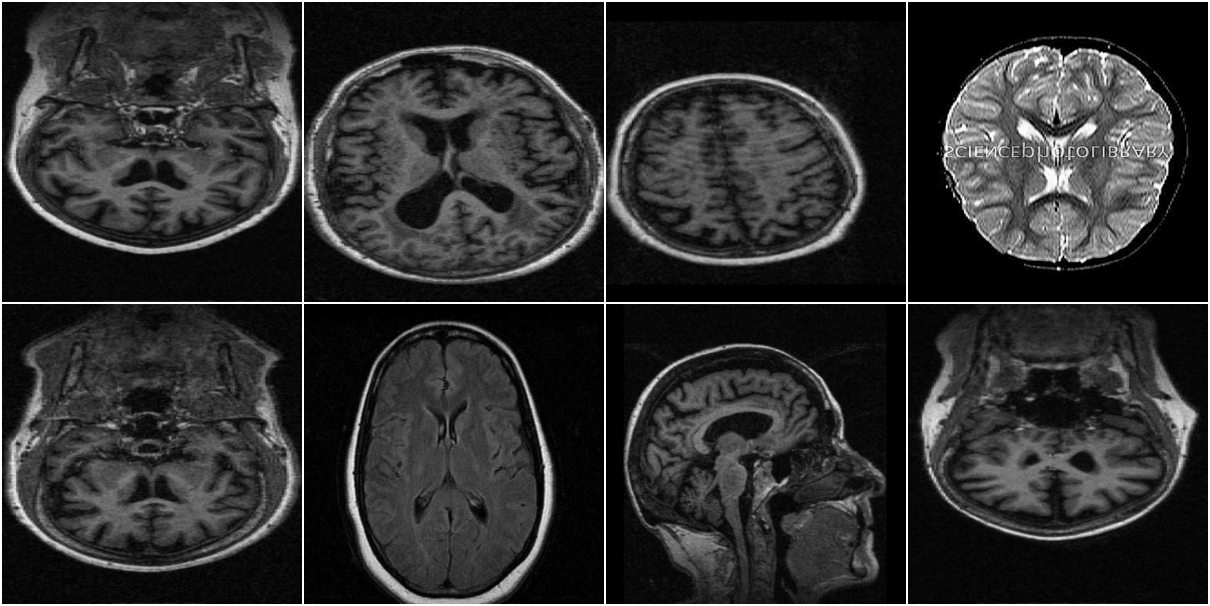

In [6]:
image_list = list(images_dir.glob("*.jpg"))

image_sample = random.sample(image_list, 8)

resize = transforms.Resize((300, 300))
gray = transforms.Grayscale()

images = []
for file in image_sample:
    img = read_image(str(file))
    img = gray(resize(img))
    images.append(img)

real_grid = make_grid(images, nrow=4, pad_value=255.0)
torchvision.transforms.ToPILImage()(real_grid)

**Transformations to resize and convert to tensor**

In [7]:
IMAGE_SIZE = 64

transformations = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64,64)),
        transforms.ToTensor()
    ]
)

transformations

Compose(
    Grayscale(num_output_channels=1)
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)